# Algorytm przyrostowy

Załadowanie potrzebnych struktur i testów

In [2]:
%run interface.ipynb
%run tests.ipynb

### Algorytm przyrostowy - wersja bez wizualizacji algorytmu

In [3]:
def orient(a, b, c):
    # Określa orientację punktów (a, b, c)
    result = a.x * b.y + b.x * c.y + a.y * c.x - c.x * b.y - b.x * a.y - a.x * c.y
    
    if result > 10e-24:
        return 1  # Przeciwnie do ruchu wskazówek zegara
    elif result < -10e-24:
        return -1 # Zgodnie z ruchem wskazówek zegara
    else:
        return 0  # Współliniowe

In [4]:
def delete_colinear(sorted_points):
    new_points = []
    new_points.append(sorted_points[0])
    last_x = sorted_points[0].x
    i = 1
    while i < len(sorted_points):
        if sorted_points[i].x != last_x:
            new_points.append(sorted_points[i])
            last_x = sorted_points[i].x
        else:
            while i < len(sorted_points) and sorted_points[i].x == last_x:
                i+=1
            i-=1
            new_points.append(sorted_points[i])
            last_x = sorted_points[i].x
        i+=1
    return new_points

In [5]:
def incremental(points):
    sorted_points2 = sorted(points, key = lambda point: (point.x, point.y))
    sorted_points = delete_colinear(sorted_points2)

    hull = []
    hull.append(sorted_points[0])
    hull.append(sorted_points[1])

    for i in range(2, len(sorted_points)):
        n = len(hull)
        point = sorted_points[i]

        upper_point_index = n - 1
        lower_point_index = n - 1
        while orient(point, hull[upper_point_index], hull[(upper_point_index + 1) % n]) <= 0:
            upper_point_index = (upper_point_index + 1) % n

        while orient(point, hull[lower_point_index], hull[(lower_point_index - 1 + n) % n]) >= 0:
            lower_point_index = (lower_point_index - 1 + n) % n

        new_hull = []
        current_index = upper_point_index
        new_hull.append(hull[upper_point_index])

        while current_index != lower_point_index:
            current_index = (current_index + 1) % n
            new_hull.append(hull[current_index])
        new_hull.append(point)

        hull = new_hull[::]

    return hull

### Algorytm przyrostowy - testy

Algorytm sortowania odpowiedzi (potrzebny do zgodności danych z odpowiedziami testów)

In [6]:
def sort_func(result, first_correct):
    index_of_first_correct = -1
    for i in range(len(result)):
        if result[i].x == first_correct.x and result[i].y == first_correct.y:
            index_of_first_correct = i
            break
    
    if index_of_first_correct == -1:
        return [] # niepoprawna odpowiedź, nie zgodzą się długości list odpowiedzi
    
    final_result = [result[index_of_first_correct]]
    for i in range(index_of_first_correct + 1, len(result)):
        final_result.append(result[i])
    for i in range(index_of_first_correct):
        final_result.append(result[i])

    return final_result

Testy poprawnościowe

In [7]:
run_test(incremental, sort_func)

Test 1:
	Czas: 0.0s
	Wynik: POPRAWNY
Test 2:
	Czas: 0.003s
	Wynik: POPRAWNY
Test 3:
	Czas: 0.0s
	Wynik: POPRAWNY
Test 4:
	Czas: 0.001s
	Wynik: POPRAWNY
PODSUMOWANIE
Wynik: 4/4
Czas: 0.004s


Testy czasowe

In [8]:
run_time_tests(incremental)

Zbiór A:
Liczba punktów: 100
Czas wykonania algorytmu: 0.0s
Liczba punktów: 500
Czas wykonania algorytmu: 0.002s
Liczba punktów: 1000
Czas wykonania algorytmu: 0.0062s
Liczba punktów: 5000
Czas wykonania algorytmu: 0.0336s
Liczba punktów: 10000
Czas wykonania algorytmu: 0.0492s
Liczba punktów: 50000
Czas wykonania algorytmu: 0.3182s
Zbiór B:
Liczba punktów: 100
Czas wykonania algorytmu: 0.0s
Liczba punktów: 500
Czas wykonania algorytmu: 0.0s
Liczba punktów: 1000
Czas wykonania algorytmu: 0.0s
Liczba punktów: 5000
Czas wykonania algorytmu: 0.0161s
Liczba punktów: 10000
Czas wykonania algorytmu: 0.0347s
Liczba punktów: 50000
Czas wykonania algorytmu: 0.1545s
Zbiór C:
Liczba punktów: 100
Czas wykonania algorytmu: 0.0s
Liczba punktów: 500
Czas wykonania algorytmu: 0.0156s
Liczba punktów: 1000
Czas wykonania algorytmu: 0.0s
Liczba punktów: 5000
Czas wykonania algorytmu: 0.0156s
Liczba punktów: 10000
Czas wykonania algorytmu: 0.0422s
Liczba punktów: 50000
Czas wykonania algorytmu: 0.2156s
Zb

### Zadawanie zbioru punktów

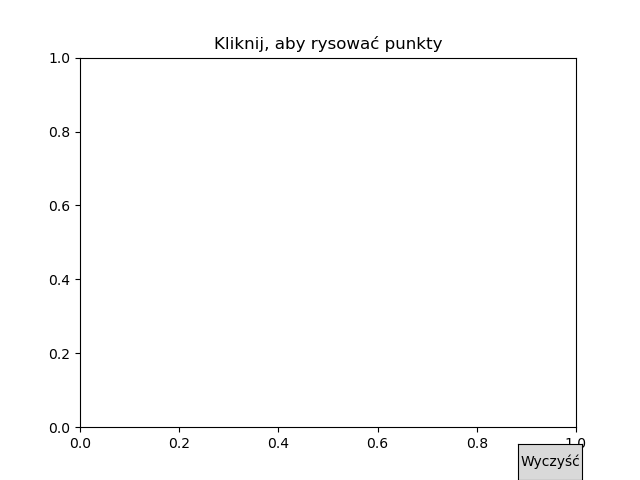

In [9]:
polygon = PolygonDrawer()

### Algorytm przyrostowy - wersja wizualizacją algorytmu

In [8]:
def incremental_visual(points):
    visualizer = ConvexHullVisualizer()
    sorted_points = sorted(points, key=lambda point: (point.x, point.y))

    hull = []
    hull.append(sorted_points[0])
    hull.append(sorted_points[1])

    visualizer.add_frame(points, [hull], [], [], None)

    for i in range(2, len(sorted_points)):
        point = sorted_points[i]
        n = len(hull)

        upper_point_index = n - 1
        lower_point_index = n - 1
        
        while orient(point, hull[upper_point_index], hull[(upper_point_index + 1) % n]) <= 0:
            upper_point_index = (upper_point_index + 1) % n

        while orient(point, hull[lower_point_index], hull[(lower_point_index - 1 + n) % n]) >= 0:
            lower_point_index = (lower_point_index - 1 + n) % n

        visualizer.add_frame(points, [hull], [], [Segment(hull[upper_point_index], point), Segment(hull[lower_point_index], point)], point)  
        
        new_hull = []
        current_index = upper_point_index
        new_hull.append(hull[upper_point_index])

        while current_index != lower_point_index:
            current_index = (current_index + 1) % n
            new_hull.append(hull[current_index])

        new_hull.append(point)
        hull = new_hull[::]

        visualizer.add_frame(points, [hull], [], [], point)

    display(visualizer.create_animation())


Wizualizacja algorytmu przyrostowego

In [12]:
incremental_visual(polygon.points)